[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/14_busqueda_informada/notebooks/02_busqueda_informada.ipynb)

# Notebook 02: Búsqueda Informada — Greedy, Dijkstra y A*

Los algoritmos del módulo anterior (BFS, DFS, IDDFS) son **búsqueda no informada**:
no saben nada sobre qué tan cerca está la meta, así que exploran a ciegas.

La **búsqueda informada** utiliza una **función heurística** $h(n)$ que estima el
costo restante desde el nodo $n$ hasta la meta. Con esta información podemos
dirigir la búsqueda hacia la meta mucho más eficientemente.

En este notebook implementamos y comparamos los tres algoritmos fundamentales:

| Algoritmo | Ordena por | Óptimo | Completo |
|-----------|-----------|--------|----------|
| **Greedy** | $h(n)$ | No | No (en general) |
| **Dijkstra** | $g(n)$ | Sí | Sí |
| **A\*** | $f(n) = g(n) + h(n)$ | Sí (si $h$ admisible) | Sí |

Donde $g(n)$ es el costo acumulado desde el inicio y $h(n)$ es la heurística.

> **Prerequisito:** haber leído `03_greedy.md`, `04_dijkstra.md` y `05_a_estrella.md`.

In [ ]:
# Solo en Colab — en entorno local estas librerías ya deben estar instaladas
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import heapq
from collections import defaultdict

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

COLORS = {
    "primary":   "#2563EB",
    "secondary": "#10B981",
    "accent":    "#F59E0B",
    "danger":    "#EF4444",
    "node":      "#93C5FD",
    "edge":      "#475569",
}

print("Dependencias cargadas correctamente.")


Dependencias cargadas correctamente.


---
## Sección 1: El Mundo de Cuadrícula con Costos

Nuestro problema de prueba será navegar una cuadrícula 2D donde:

- `'#'` es una pared (infranqueable)
- Las demás celdas tienen un **costo de terreno** $c \geq 1$
- Moverse a una celda cuesta $c$ (el costo del terreno destino)
- Movimientos: arriba, abajo, izquierda, derecha (4-conectividad)

La **heurística de Manhattan** es admisible para este problema:

$$h(n) = |r_n - r_{meta}| + |c_n - c_{meta}|$$

Es admisible porque en el mejor caso (sin paredes ni costos extra) el costo real
es exactamente la distancia Manhattan; nunca sobreestimamos.

Cuando hay costos de terreno $> 1$, la heurística sigue siendo admisible porque
$h(n) \leq$ costo real (estamos ignorando los costos extra).

In [3]:
class GridProblem:
    """
    Problema de búsqueda en cuadrícula 2D con costos de terreno variables.

    Parámetros
    ----------
    grid : list[list[str]]
        Cuadrícula donde '#' = pared y cualquier otro carácter = celda libre.
    inicio : tuple (fila, col)
    meta   : tuple (fila, col)
    terrain_cost : dict
        Mapea caracteres de celda a su costo. Por ejemplo {'.' : 1, 'S' : 3}.
        Si una celda no aparece en el dict, se asume costo 1.
    """

    DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def __init__(self, grid, inicio, meta, terrain_cost=None):
        self.grid = grid
        self.inicio = inicio
        self.meta = meta
        self.filas = len(grid)
        self.cols = len(grid[0])
        self.terrain_cost = terrain_cost or {}

    def es_meta(self, nodo):
        return nodo == self.meta

    def costo_celda(self, r, c):
        """Costo de entrar a la celda (r, c)."""
        return self.terrain_cost.get(self.grid[r][c], 1)

    def vecinos(self, nodo):
        """
        Devuelve lista de (vecino, costo) para los movimientos válidos
        desde nodo.
        """
        r, c = nodo
        resultado = []
        for dr, dc in self.DIRS:
            nr, nc = r + dr, c + dc
            if (0 <= nr < self.filas and
                    0 <= nc < self.cols and
                    self.grid[nr][nc] != '#'):
                resultado.append(((nr, nc), self.costo_celda(nr, nc)))
        return resultado

    def heuristica_manhattan(self, nodo):
        """Distancia Manhattan al nodo meta."""
        r, c = nodo
        mr, mc = self.meta
        return abs(r - mr) + abs(c - mc)


print("GridProblem definido.")

# Test básico
grid_test = [
    ['.', '.', '#'],
    ['.', '.', '.'],
    ['#', '.', '.'],
]
p_test = GridProblem(grid_test, (0, 0), (2, 2))
print("Vecinos de (0,0):", p_test.vecinos((0, 0)))
print("Heurística en (0,0):", p_test.heuristica_manhattan((0, 0)))
print("Heurística en (1,1):", p_test.heuristica_manhattan((1, 1)))


GridProblem definido.
Vecinos de (0,0): [((1, 0), 1), ((0, 1), 1)]
Heurística en (0,0): 4
Heurística en (1,1): 2


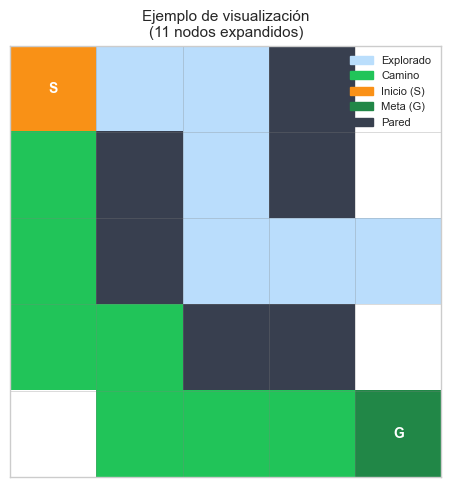

In [4]:
def visualizar_grid(
    problema,
    camino=None,
    explorados=None,
    titulo="",
    ax=None,
    mostrar_conteo=True
):
    """
    Visualiza la cuadrícula con:
    - celdas exploradas en azul claro
    - camino en verde
    - inicio en naranja, meta en verde oscuro
    - paredes en gris oscuro
    - terreno costoso en amarillo claro

    Parámetros
    ----------
    problema   : GridProblem
    camino     : lista de celdas (fila, col)
    explorados : conjunto de celdas expandidas
    titulo     : str
    ax         : matplotlib Axes (si None, crea uno nuevo)
    mostrar_conteo : bool — si True, añade el conteo al título
    """
    grid = problema.grid
    filas, cols = problema.filas, problema.cols
    inicio, meta = problema.inicio, problema.meta

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    img = np.ones((filas, cols, 3))

    for r in range(filas):
        for c in range(cols):
            celda = grid[r][c]
            if celda == '#':
                img[r, c] = [0.22, 0.25, 0.31]  # pared
            elif problema.costo_celda(r, c) > 1:
                img[r, c] = [0.99, 0.95, 0.75]  # terreno costoso

    if explorados:
        for (r, c) in explorados:
            if (r, c) not in (inicio, meta):
                img[r, c] = [0.73, 0.87, 0.99]  # explorado: azul claro

    if camino:
        for (r, c) in camino:
            if (r, c) not in (inicio, meta):
                img[r, c] = [0.13, 0.77, 0.35]  # camino: verde

    img[inicio[0], inicio[1]] = [0.98, 0.57, 0.09]  # inicio: naranja
    img[meta[0],   meta[1]]   = [0.13, 0.53, 0.28]  # meta: verde oscuro

    ax.imshow(img, interpolation='nearest', aspect='equal')

    # Etiquetas de inicio/meta
    ax.text(inicio[1], inicio[0], 'S', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(meta[1], meta[0], 'G', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

    # Cuadrícula
    for x in range(cols + 1):
        ax.axvline(x - 0.5, color='gray', linewidth=0.4, alpha=0.5)
    for y in range(filas + 1):
        ax.axhline(y - 0.5, color='gray', linewidth=0.4, alpha=0.5)

    titulo_completo = titulo
    if mostrar_conteo and explorados is not None:
        titulo_completo += f"\n({len(explorados)} nodos expandidos)"
    ax.set_title(titulo_completo, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


# Test de visualización con un laberinto pequeño
grid_vis = [
    ['.', '.', '.', '#', '.'],
    ['.', '#', '.', '#', '.'],
    ['.', '#', '.', '.', '.'],
    ['.', '.', '#', '#', '.'],
    ['.', '.', '.', '.', '.'],
]
prob_vis = GridProblem(grid_vis, (0, 0), (4, 4))
explorados_demo = {(0,0),(0,1),(0,2),(1,0),(1,2),(2,0),(2,2),(2,3),(2,4),(3,0),(3,1)}
camino_demo = [(0,0),(1,0),(2,0),(3,0),(3,1),(4,1),(4,2),(4,3),(4,4)]

fig, ax = plt.subplots(figsize=(5, 5))
visualizar_grid(prob_vis, camino=camino_demo, explorados=explorados_demo,
                titulo="Ejemplo de visualización", ax=ax)

parches = [
    mpatches.Patch(color=[0.73, 0.87, 0.99], label='Explorado'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Camino'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.53, 0.28], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
]
ax.legend(handles=parches, loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Sección 2: Los Tres Algoritmos

Los tres algoritmos comparten la misma estructura de frontera de prioridad.
Lo que cambia es **qué valor se usa como prioridad**:

- **Greedy**: prioridad = $h(n)$ (solo la heurística)
- **Dijkstra**: prioridad = $g(n)$ (solo el costo acumulado)
- **A\***: prioridad = $f(n) = g(n) + h(n)$ (suma de ambos)

### Clase PriorityFrontier (de Notebook 01)

Reusamos la misma implementación. La incluimos aquí para que el notebook
sea autocontenido.

In [5]:
class PriorityFrontier:
    """Frontera de prioridad con lazy deletion (ver Notebook 01)."""

    def __init__(self):
        self._heap = []
        self._mejor = {}
        self._contador = 0

    def push(self, nodo, prioridad):
        heapq.heappush(self._heap, (prioridad, self._contador, nodo))
        self._mejor[nodo] = prioridad
        self._contador += 1

    def push_or_update(self, nodo, prioridad):
        if nodo not in self._mejor or prioridad < self._mejor[nodo]:
            self.push(nodo, prioridad)
            return True
        return False

    def pop(self):
        while self._heap:
            prio, _, nodo = heapq.heappop(self._heap)
            if nodo in self._mejor and self._mejor[nodo] == prio:
                del self._mejor[nodo]
                return nodo, prio
        raise IndexError("pop de frontera vacía")

    def contains(self, nodo):  return nodo in self._mejor
    def is_empty(self):        return len(self._mejor) == 0
    def best_cost(self, nodo): return self._mejor.get(nodo, float('inf'))


print("PriorityFrontier lista.")


PriorityFrontier lista.


In [6]:
def greedy(problema, h):
    """
    Búsqueda greedy (mejor primero).
    Ordena la frontera solo por h(n) — ignora el costo acumulado.

    Retorna (camino, explorado_count, explorados_set)
    """
    frontera = PriorityFrontier()
    frontera.push(problema.inicio, h(problema.inicio))

    padre = {problema.inicio: None}
    explorados = set()

    while not frontera.is_empty():
        nodo, _ = frontera.pop()

        if problema.es_meta(nodo):
            return _reconstruir(padre, nodo), len(explorados), explorados

        explorados.add(nodo)

        for vecino, _ in problema.vecinos(nodo):   # ignoramos el costo
            if vecino not in explorados and not frontera.contains(vecino):
                padre[vecino] = nodo
                frontera.push_or_update(vecino, h(vecino))

    return None, len(explorados), explorados


def dijkstra(problema):
    """
    Algoritmo de Dijkstra (Uniform Cost Search).
    Ordena la frontera por g(n) — costo acumulado desde el inicio.

    Retorna (camino, explorado_count, explorados_set)
    """
    frontera = PriorityFrontier()
    frontera.push(problema.inicio, 0)

    g = {problema.inicio: 0}   # costo acumulado
    padre = {problema.inicio: None}
    explorados = set()

    while not frontera.is_empty():
        nodo, costo = frontera.pop()

        if problema.es_meta(nodo):
            return _reconstruir(padre, nodo), len(explorados), explorados

        explorados.add(nodo)

        for vecino, peso in problema.vecinos(nodo):
            if vecino in explorados:
                continue
            nuevo_g = costo + peso
            if nuevo_g < g.get(vecino, float('inf')):
                g[vecino] = nuevo_g
                padre[vecino] = nodo
                frontera.push_or_update(vecino, nuevo_g)

    return None, len(explorados), explorados


def a_star(problema, h):
    """
    Algoritmo A*.
    Ordena la frontera por f(n) = g(n) + h(n).
    Si h es admisible, garantiza el camino de menor costo.

    Retorna (camino, explorado_count, explorados_set)
    """
    frontera = PriorityFrontier()
    f0 = 0 + h(problema.inicio)
    frontera.push(problema.inicio, f0)

    g = {problema.inicio: 0}
    padre = {problema.inicio: None}
    explorados = set()

    while not frontera.is_empty():
        nodo, _ = frontera.pop()

        if problema.es_meta(nodo):
            return _reconstruir(padre, nodo), len(explorados), explorados

        explorados.add(nodo)

        for vecino, peso in problema.vecinos(nodo):
            if vecino in explorados:
                continue
            nuevo_g = g[nodo] + peso
            if nuevo_g < g.get(vecino, float('inf')):
                g[vecino] = nuevo_g
                padre[vecino] = nodo
                f = nuevo_g + h(vecino)
                frontera.push_or_update(vecino, f)

    return None, len(explorados), explorados


def _reconstruir(padre, meta):
    """Reconstruye el camino desde el inicio hasta la meta usando el dict padre."""
    camino = []
    nodo = meta
    while nodo is not None:
        camino.append(nodo)
        nodo = padre[nodo]
    camino.reverse()
    return camino


print("Algoritmos greedy, dijkstra y a_star definidos.")

# Test rápido en laberinto pequeño
grid_small = [
    ['.', '.', '#', '.'],
    ['.', '#', '.', '.'],
    ['.', '.', '.', '#'],
    ['#', '.', '.', '.'],
]
prob_small = GridProblem(grid_small, (0, 0), (3, 3))
h_m = prob_small.heuristica_manhattan

c_g, exp_g, _ = greedy(prob_small, h_m)
c_d, exp_d, _ = dijkstra(prob_small)
c_a, exp_a, _ = a_star(prob_small, h_m)

print(f"Greedy:   camino={c_g}, expansiones={exp_g}")
print(f"Dijkstra: camino={c_d}, expansiones={exp_d}")
print(f"A*:       camino={c_a}, expansiones={exp_a}")

# Dijkstra y A* deben encontrar caminos óptimos de igual longitud
assert len(c_d) == len(c_a), "Dijkstra y A* deben encontrar caminos del mismo costo"
print("\n✓ Dijkstra y A* coinciden en longitud óptima.")


Algoritmos greedy, dijkstra y a_star definidos.
Greedy:   camino=[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)], expansiones=6
Dijkstra: camino=[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)], expansiones=9
A*:       camino=[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)], expansiones=8

✓ Dijkstra y A* coinciden en longitud óptima.


In [7]:
def costo_total_camino(problema, camino):
    """Calcula el costo total de un camino en GridProblem."""
    costo = 0
    for i in range(1, len(camino)):
        r, c = camino[i]
        costo += problema.costo_celda(r, c)
    return costo


print("Costos en el laberinto pequeño:")
for nombre, camino in [('Greedy', c_g), ('Dijkstra', c_d), ('A*', c_a)]:
    print(f"  {nombre:<10} longitud={len(camino)}, costo_total={costo_total_camino(prob_small, camino)}")


Costos en el laberinto pequeño:
  Greedy     longitud=7, costo_total=6
  Dijkstra   longitud=7, costo_total=6
  A*         longitud=7, costo_total=6


---
## Sección 3: Comparación Visual en un Laberinto 15×15

Para ver las diferencias reales entre los tres algoritmos, usamos un laberinto
más grande con:

- Una **pared horizontal** que obliga a los algoritmos a rodear
- Dos tipos de **terreno**: normal (costo 1) y costoso (costo 3, marcado como `'S'`)

Observa:
- **Greedy** va directamente hacia la meta pero puede suboptimizar
- **Dijkstra** encuentra el camino de menor costo pero explora mucho más
- **A\*** equilibra costo y dirección: expande menos que Dijkstra y mantiene optimalidad

In [8]:
def construir_laberinto_15x15():
    """
    Construye un laberinto 15×15 con:
    - Pared horizontal en la fila 7 (filas 5-9, col 1-11)
    - Zona de terreno costoso (costo 3) en columnas 4-9, filas 0-4
    - Un corredor estrecho para pasar la pared
    """
    filas, cols = 15, 15
    grid = [['.' for _ in range(cols)] for _ in range(filas)]

    # Pared horizontal en fila 7, columnas 1 a 12 (deja paso en col 13)
    for c in range(1, 13):
        grid[7][c] = '#'

    # Zona de terreno costoso (costo 3): filas 0-5, columnas 4-9
    for r in range(0, 6):
        for c in range(4, 10):
            if grid[r][c] != '#':
                grid[r][c] = 'S'  # 'S' = slow / lento

    # Añadir algunas paredes extra para hacer el laberinto más interesante
    paredes_extra = [
        (2, 2), (3, 2), (4, 2),
        (10, 3), (11, 3), (12, 3),
        (10, 8), (11, 8),
        (3, 12), (4, 12), (5, 12),
    ]
    for r, c in paredes_extra:
        grid[r][c] = '#'

    return grid


grid_15 = construir_laberinto_15x15()
inicio_15 = (0, 0)
meta_15   = (14, 14)

# terrain_cost: 'S' cuesta 3, '.' cuesta 1
terrain = {'.': 1, 'S': 3}
prob_15 = GridProblem(grid_15, inicio_15, meta_15, terrain_cost=terrain)

print(f"Laberinto {prob_15.filas}×{prob_15.cols} creado.")
print(f"Inicio: {inicio_15}, Meta: {meta_15}")

# Contar celdas por tipo
n_libres  = sum(1 for r in grid_15 for c in r if c != '#')
n_paredes = sum(1 for r in grid_15 for c in r if c == '#')
n_lentos  = sum(1 for r in grid_15 for c in r if c == 'S')
print(f"Celdas libres: {n_libres} (de las cuales {n_lentos} son terreno lento)")
print(f"Paredes: {n_paredes}")


Laberinto 15×15 creado.
Inicio: (0, 0), Meta: (14, 14)
Celdas libres: 202 (de las cuales 36 son terreno lento)
Paredes: 23


In [9]:
# Ejecutar los tres algoritmos
h_15 = prob_15.heuristica_manhattan

camino_greedy,  exp_greedy,  expl_greedy  = greedy(prob_15, h_15)
camino_dijkstra, exp_dijkstra, expl_dijkstra = dijkstra(prob_15)
camino_astar,   exp_astar,   expl_astar   = a_star(prob_15, h_15)

print("Resultados en laberinto 15×15:")
print(f"{'Algoritmo':<12} {'Nodos expandidos':>18} {'Longitud camino':>16} {'Costo total':>12}")
print("-" * 62)
for nombre, camino, exp in [
    ('Greedy',   camino_greedy,   exp_greedy),
    ('Dijkstra', camino_dijkstra, exp_dijkstra),
    ('A*',       camino_astar,    exp_astar),
]:
    if camino:
        ct = costo_total_camino(prob_15, camino)
        print(f"{nombre:<12} {exp:>18} {len(camino):>16} {ct:>12}")
    else:
        print(f"{nombre:<12} {'—':>18} {'sin solución':>16}")


Resultados en laberinto 15×15:
Algoritmo      Nodos expandidos  Longitud camino  Costo total
--------------------------------------------------------------
Greedy                       28               29           28
Dijkstra                    201               29           28
A*                          138               29           28


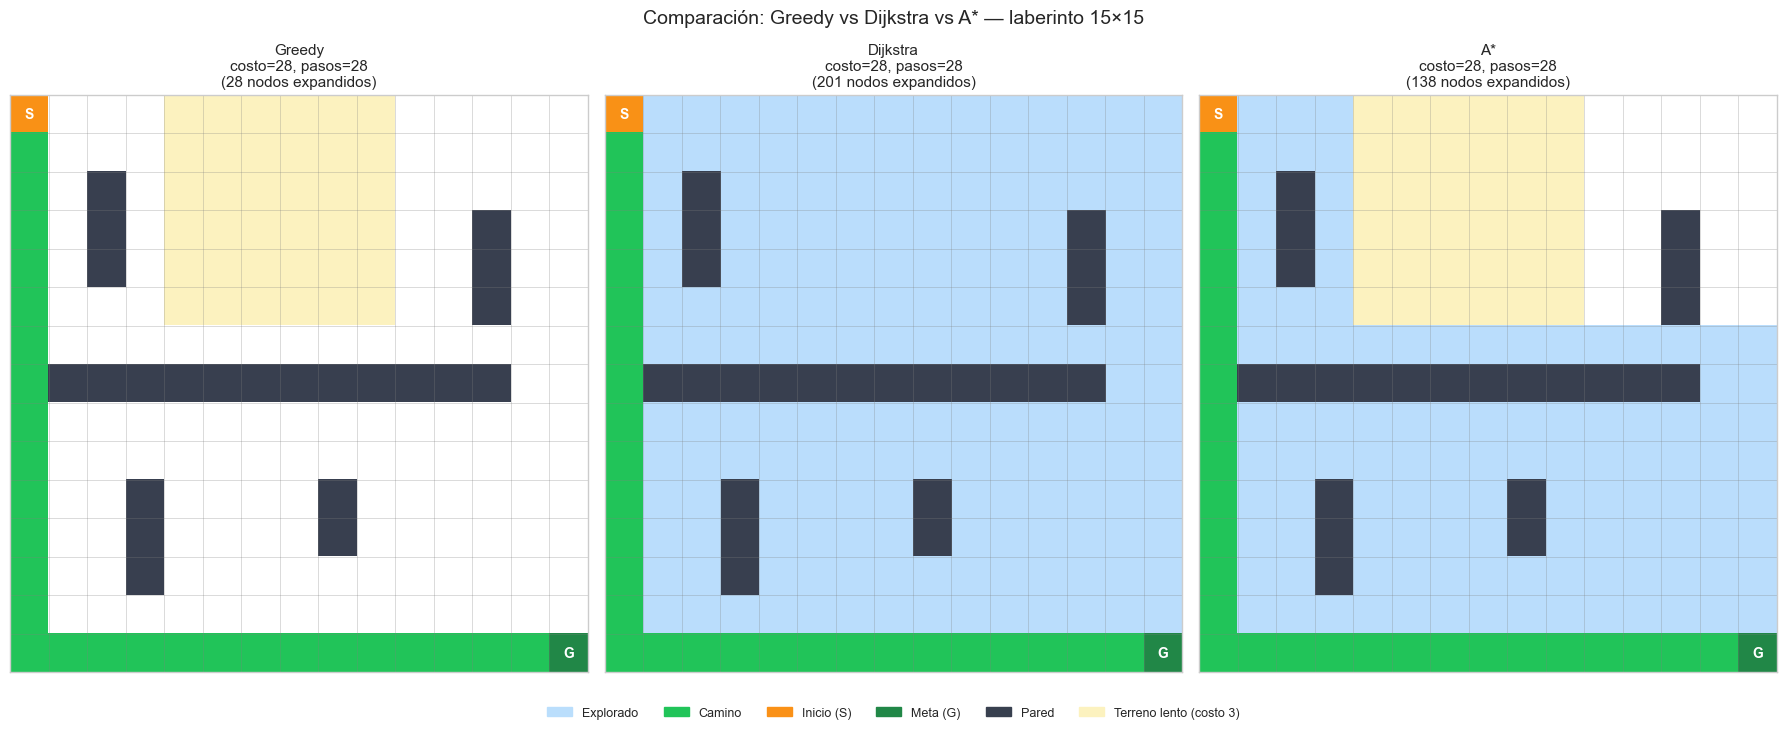

In [10]:
# Comparación visual: 3 paneles lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

algoritmos_info = [
    ('Greedy',   camino_greedy,   expl_greedy,   exp_greedy),
    ('Dijkstra', camino_dijkstra, expl_dijkstra, exp_dijkstra),
    ('A*',       camino_astar,    expl_astar,    exp_astar),
]

for ax, (nombre, camino, explorados, n_exp) in zip(axes, algoritmos_info):
    if camino:
        ct = costo_total_camino(prob_15, camino)
        titulo = f"{nombre}\ncosto={ct}, pasos={len(camino)-1}"
    else:
        titulo = f"{nombre}\nsin solución"
    visualizar_grid(prob_15, camino=camino, explorados=explorados,
                    titulo=titulo, ax=ax, mostrar_conteo=True)

# Leyenda compartida
parches = [
    mpatches.Patch(color=[0.73, 0.87, 0.99], label='Explorado'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Camino'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.53, 0.28], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
    mpatches.Patch(color=[0.99, 0.95, 0.75], label='Terreno lento (costo 3)'),
]
fig.legend(handles=parches, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Comparación: Greedy vs Dijkstra vs A* — laberinto 15×15",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


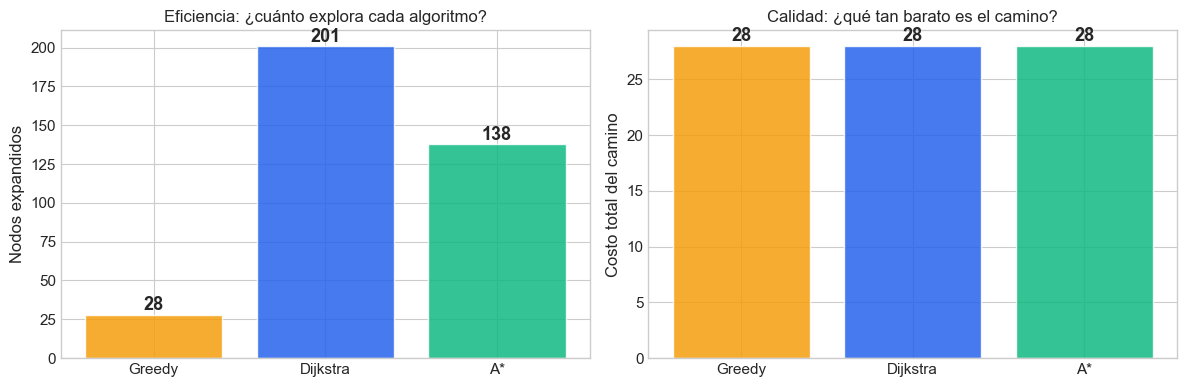

Observaciones:
• Greedy expande pocos nodos pero puede encontrar un camino subóptimo.
• Dijkstra garantiza el costo mínimo, pero puede explorar muchas celdas.
• A* equilibra: encuentra el óptimo y expande menos nodos que Dijkstra.


In [11]:
# Gráfica de barras resumen
nombres = ['Greedy', 'Dijkstra', 'A*']
n_expandidos = [exp_greedy, exp_dijkstra, exp_astar]
costos = [
    costo_total_camino(prob_15, camino_greedy),
    costo_total_camino(prob_15, camino_dijkstra),
    costo_total_camino(prob_15, camino_astar),
]
colores_bar = [COLORS["accent"], COLORS["primary"], COLORS["secondary"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(nombres, n_expandidos, color=colores_bar, alpha=0.85, edgecolor='white')
axes[0].set_ylabel("Nodos expandidos", fontsize=12)
axes[0].set_title("Eficiencia: ¿cuánto explora cada algoritmo?", fontsize=12)
for i, v in enumerate(n_expandidos):
    axes[0].text(i, v + 0.2, str(v), ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

axes[1].bar(nombres, costos, color=colores_bar, alpha=0.85, edgecolor='white')
axes[1].set_ylabel("Costo total del camino", fontsize=12)
axes[1].set_title("Calidad: ¿qué tan barato es el camino?", fontsize=12)
for i, v in enumerate(costos):
    axes[1].text(i, v + 0.1, str(v), ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Observaciones:")
print("• Greedy expande pocos nodos pero puede encontrar un camino subóptimo.")
print("• Dijkstra garantiza el costo mínimo, pero puede explorar muchas celdas.")
print("• A* equilibra: encuentra el óptimo y expande menos nodos que Dijkstra.")


---
## Ejercicio 1

Modifica el `GridProblem` para agregar zonas de **terreno costoso** (costo = 3) y
**terreno normal** (costo = 1) en un laberinto de tu elección.

Ejecuta los tres algoritmos y compara cuántos nodos expande cada uno.
¿Cambia el camino encontrado por Greedy si agrega terreno costoso justo en su ruta directa?

**Requisitos:**
- Laberinto de al menos 10×10
- Al menos una zona de terreno costoso (costo 3)
- Visualización comparativa de los tres algoritmos
- Tabla con nodos expandidos y costo total para cada algoritmo

Laberinto: 12x12
Celdas costosas (S): 13

Algoritmo  Nodos expandidos    Pasos  Costo total
----------------------------------------------------
Greedy                   22       22           38
Dijkstra                 97       22           22
A*                       58       22           22


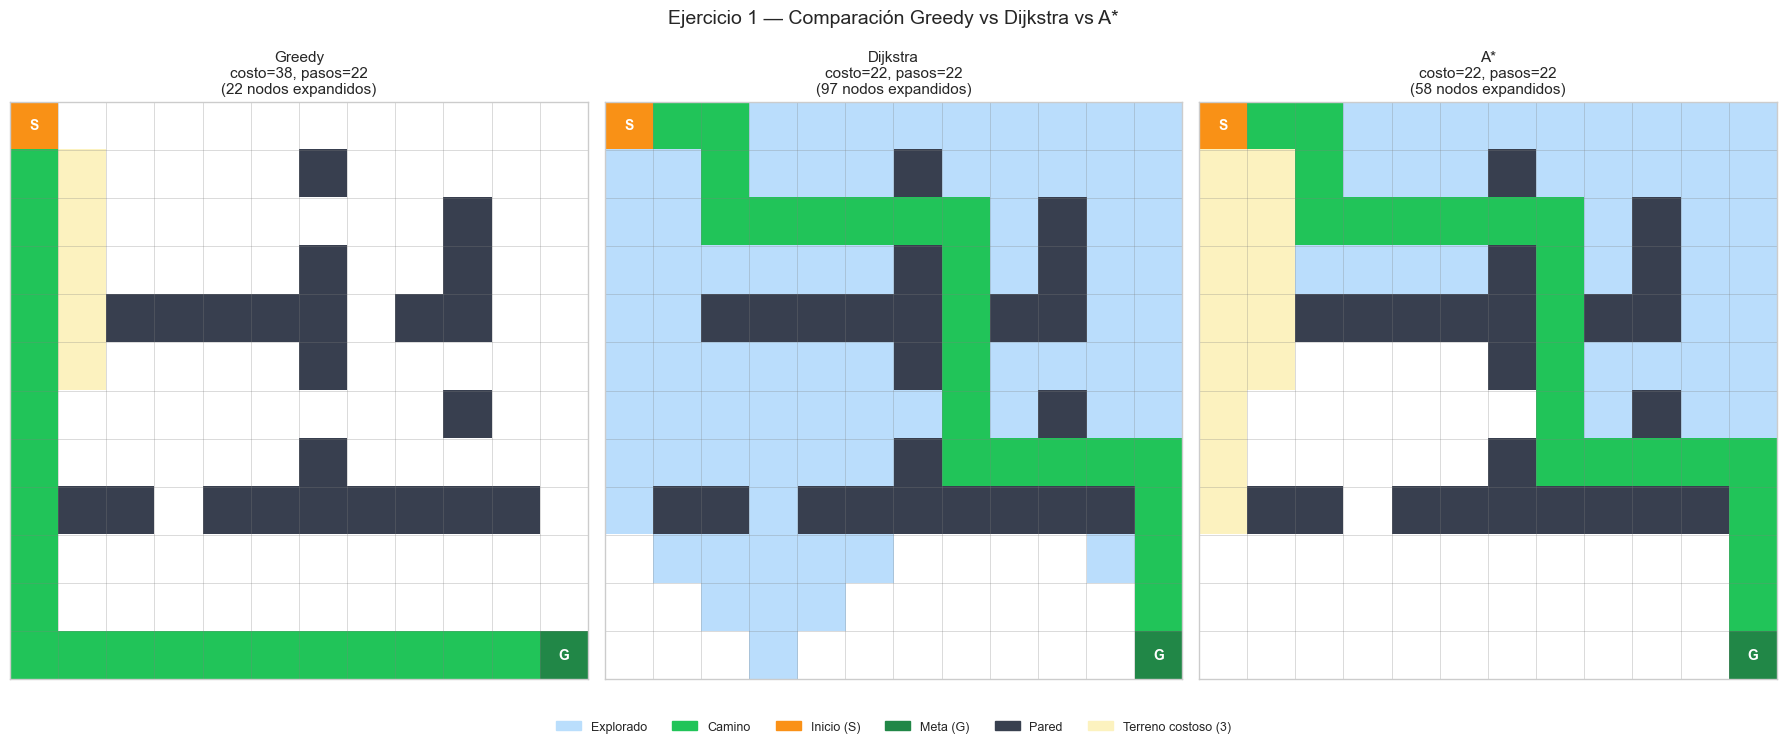


¿Cambia el camino encontrado por Greedy al agregar terreno costoso en su ruta directa?
No
Greedy no cambia porque prioriza solo h(n), no el costo real del terreno.


In [12]:

filas, cols = 12, 12
mi_grid_base = [['.' for _ in range(cols)] for _ in range(filas)]

# Paredes para formar un laberinto
for c in range(2, 10):
    mi_grid_base[4][c] = '#';
mi_grid_base[4][7] = '.'  # abertura

for c in range(1, 11):
    mi_grid_base[8][c] = '#';
mi_grid_base[8][3] = '.'  # abertura

for r in range(1, 9):
    mi_grid_base[r][6] = '#';
mi_grid_base[2][6] = '.'  # abertura
mi_grid_base[6][6] = '.'  # abertura

for r in range(2, 7):
    mi_grid_base[r][9] = '#';
mi_grid_base[5][9] = '.'  # abertura

mi_inicio = (0, 0)
mi_meta = (11, 11)
mi_terrain = {'.': 1, 'S': 3}

prob_base = GridProblem(mi_grid_base, mi_inicio, mi_meta, terrain_cost=mi_terrain)
h_base = prob_base.heuristica_manhattan
camino_g_base, _, _ = greedy(prob_base, h_base)
assert camino_g_base is not None, "Greedy no encontró camino en el laberinto base"

# Agregar terreno costoso justo sobre parte de la ruta directa de Greedy
mi_grid = [fila[:] for fila in mi_grid_base]
zona_costosa = set()

for (r, c) in camino_g_base[1:9]:
    if mi_grid[r][c] != '#':
        mi_grid[r][c] = 'S'
        zona_costosa.add((r, c))

# Ensanchar la zona para que sea más visible
for r in range(1, 6):
    if mi_grid[r][1] != '#':
        mi_grid[r][1] = 'S'
        zona_costosa.add((r, 1))

mi_prob = GridProblem(mi_grid, mi_inicio, mi_meta, terrain_cost=mi_terrain)
h = mi_prob.heuristica_manhattan

# Verificaciones de requisitos
assert mi_prob.filas >= 10 and mi_prob.cols >= 10, "El laberinto debe ser al menos 10x10"
n_costoso = sum(1 for fila in mi_grid for celda in fila if celda == 'S')
assert n_costoso >= 1, "Debe existir al menos una zona de terreno costoso"

# Ejecutar los tres algoritmos
camino_g, exp_g, expl_g = greedy(mi_prob, h)
camino_d, exp_d, expl_d = dijkstra(mi_prob)
camino_a, exp_a, expl_a = a_star(mi_prob, h)

resultados = [
    ('Greedy', camino_g, exp_g, expl_g),
    ('Dijkstra', camino_d, exp_d, expl_d),
    ('A*', camino_a, exp_a, expl_a),
]

# Tabla con nodos expandidos y costo total
print(f"Laberinto: {mi_prob.filas}x{mi_prob.cols}")
print(f"Celdas costosas (S): {n_costoso}")
print()
print(f"{'Algoritmo':<10} {'Nodos expandidos':>16} {'Pasos':>8} {'Costo total':>12}")
print("-" * 52)
for nombre, camino, exp, _ in resultados:
    if camino is None:
        print(f"{nombre:<10} {exp:>16} {'—':>8} {'sin ruta':>12}")
    else:
        costo = costo_total_camino(mi_prob, camino)
        pasos = len(camino) - 1
        print(f"{nombre:<10} {exp:>16} {pasos:>8} {costo:>12}")

# Visualización comparativa de los tres algoritmos
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (nombre, camino, exp, explorados) in zip(axes, resultados):
    if camino is None:
        titulo = f"{nombre}\nsin ruta"
    else:
        costo = costo_total_camino(mi_prob, camino)
        titulo = f"{nombre}\ncosto={costo}, pasos={len(camino)-1}"
    visualizar_grid(mi_prob, camino=camino, explorados=explorados,
                    titulo=titulo, ax=ax, mostrar_conteo=True)

parches = [
    mpatches.Patch(color=[0.73, 0.87, 0.99], label='Explorado'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Camino'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.53, 0.28], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
    mpatches.Patch(color=[0.99, 0.95, 0.75], label='Terreno costoso (3)'),
]
fig.legend(handles=parches, loc='lower center', ncol=6, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Ejercicio 1 — Comparación Greedy vs Dijkstra vs A*', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ¿Cambia Greedy al poner terreno costoso sobre su ruta directa?
cambio_greedy = camino_g_base != camino_g
print()
print("¿Cambia el camino encontrado por Greedy al agregar terreno costoso en su ruta directa?")
print("Sí" if cambio_greedy else "No")
if not cambio_greedy:
    print("Greedy no cambia porque prioriza solo h(n), no el costo real del terreno.")
else:
    print("En este laberinto sí cambió por efecto de desempates/estructura de paredes.")

---
## Ejercicio 2

Verifica **empíricamente** que $h = 0$ produce exactamente el mismo comportamiento
que Dijkstra.

La teoría dice: si $h(n) = 0$ para todo $n$, entonces $f(n) = g(n) + 0 = g(n)$,
y A\* se convierte en Dijkstra.

Muestra que `a_star(prob, h=lambda n: 0)` expande exactamente los mismos nodos
que `dijkstra(prob)` en al menos 3 laberintos distintos.

**Pista:** Compara los conjuntos `explorados` devueltos por ambas funciones.

In [13]:
def h_cero(nodo):
    """Heurística nula: siempre devuelve 0."""
    return 0

def construir_lab_10():
    """Laberinto 10x10 con paredes y zona costosa 'S'."""
    filas, cols = 10, 10
    grid = [['.' for _ in range(cols)] for _ in range(filas)]

    # Barreras principales
    for c in range(1, 9):
        grid[5][c] = '#'
    grid[5][4] = '.'  # abertura

    for r in range(1, 8):
        grid[r][6] = '#'
    grid[3][6] = '.'  # abertura

    # Zona costosa
    for r in range(0, 4):
        for c in range(2, 5):
            if grid[r][c] != '#':
                grid[r][c] = 'S'

    # Paredes extra
    for r, c in [(7, 2), (7, 3), (7, 4), (2, 8), (3, 8)]:
        grid[r][c] = '#'

    return grid

def construir_lab_12():
    """Laberinto 12x12 con paredes y zona costosa 'S'."""
    filas, cols = 12, 12
    grid = [['.' for _ in range(cols)] for _ in range(filas)]

    for c in range(2, 10):
        grid[4][c] = '#'
    grid[4][7] = '.'

    for c in range(1, 11):
        grid[8][c] = '#'
    grid[8][3] = '.'

    for r in range(1, 9):
        grid[r][6] = '#'
    grid[2][6] = '.'
    grid[6][6] = '.'

    for r in range(2, 7):
        grid[r][9] = '#'
    grid[5][9] = '.'

    # Zona costosa
    for r in range(1, 6):
        if grid[r][1] != '#':
            grid[r][1] = 'S'
    for c in range(1, 5):
        if grid[0][c] != '#':
            grid[0][c] = 'S'

    return grid

# Laberinto 1 (pequeño), 2 (10x10), 3 (12x12)
grid_1 = [
    ['.', '.', '#', '.'],
    ['.', '#', '.', '.'],
    ['.', '.', '.', '#'],
    ['#', '.', '.', '.'],
]
grid_2 = construir_lab_10()
grid_3 = construir_lab_12()

laberintos = [
    ('Lab 1 (4x4)', grid_1, (0, 0), (3, 3), {'.': 1, 'S': 3}),
    ('Lab 2 (10x10)', grid_2, (0, 0), (9, 9), {'.': 1, 'S': 3}),
    ('Lab 3 (12x12)', grid_3, (0, 0), (11, 11), {'.': 1, 'S': 3}),
]

print(f"{'Laberinto':<16} {'Exp Dijkstra':>12} {'Exp A*(h=0)':>12} {'Mismos sets':>12} {'Costo D':>10} {'Costo A*0':>10}")
print("-" * 78)

for i, (nombre, grid, inicio, meta, tc) in enumerate(laberintos, start=1):
    prob = GridProblem(grid, inicio, meta, terrain_cost=tc)

    camino_d, exp_d, expl_d = dijkstra(prob)
    camino_a0, exp_a0, expl_a0 = a_star(prob, h_cero)

    assert camino_d is not None and camino_a0 is not None, f"{nombre}: no hay camino"
    costo_d = costo_total_camino(prob, camino_d)
    costo_a0 = costo_total_camino(prob, camino_a0)

    mismos_sets = (expl_d == expl_a0)
    print(f"{nombre:<16} {exp_d:>12} {exp_a0:>12} {str(mismos_sets):>12} {costo_d:>10} {costo_a0:>10}")

    # Verificación empírica central del ejercicio
    assert mismos_sets, f"{nombre}: los conjuntos de explorados difieren"
    assert exp_d == exp_a0, f"{nombre}: difiere número de nodos expandidos"
    assert costo_d == costo_a0, f"{nombre}: difiere costo de solución"

print("\n✓ En los 3 laberintos, A*(h=0) y Dijkstra expanden exactamente los mismos nodos.")

Laberinto        Exp Dijkstra  Exp A*(h=0)  Mismos sets    Costo D  Costo A*0
------------------------------------------------------------------------------
Lab 1 (4x4)                 9            9         True          6          6
Lab 2 (10x10)              80           80         True         18         18
Lab 3 (12x12)             120          120         True         22         22

✓ En los 3 laberintos, A*(h=0) y Dijkstra expanden exactamente los mismos nodos.


---
## Ejercicio 3

Prueba una **heurística inadmisible**: $h_{\text{inad}}(n) = \text{manhattan}(n) \times 2$.

Una heurística es **inadmisible** si sobreestima el costo real ($h(n) > h^*(n)$ para algún $n$).
A\* con heurística inadmisible puede encontrar caminos **subóptimos**.

Responde:
1. ¿Qué camino devuelve A\* con $h_{\text{inad}}$?
2. ¿Es óptimo? Compara su costo con Dijkstra.
3. ¿Expande más o menos nodos que A\* con la heurística admisible?
4. ¿Por qué la inadmisibilidad rompe la garantía de optimalidad?

Algoritmo                Expandidos    Pasos    Costo
------------------------------------------------------
Dijkstra                        201       28       28
A* (h admisible)                138       28       28
A* (h inadmisible)               28       28       28


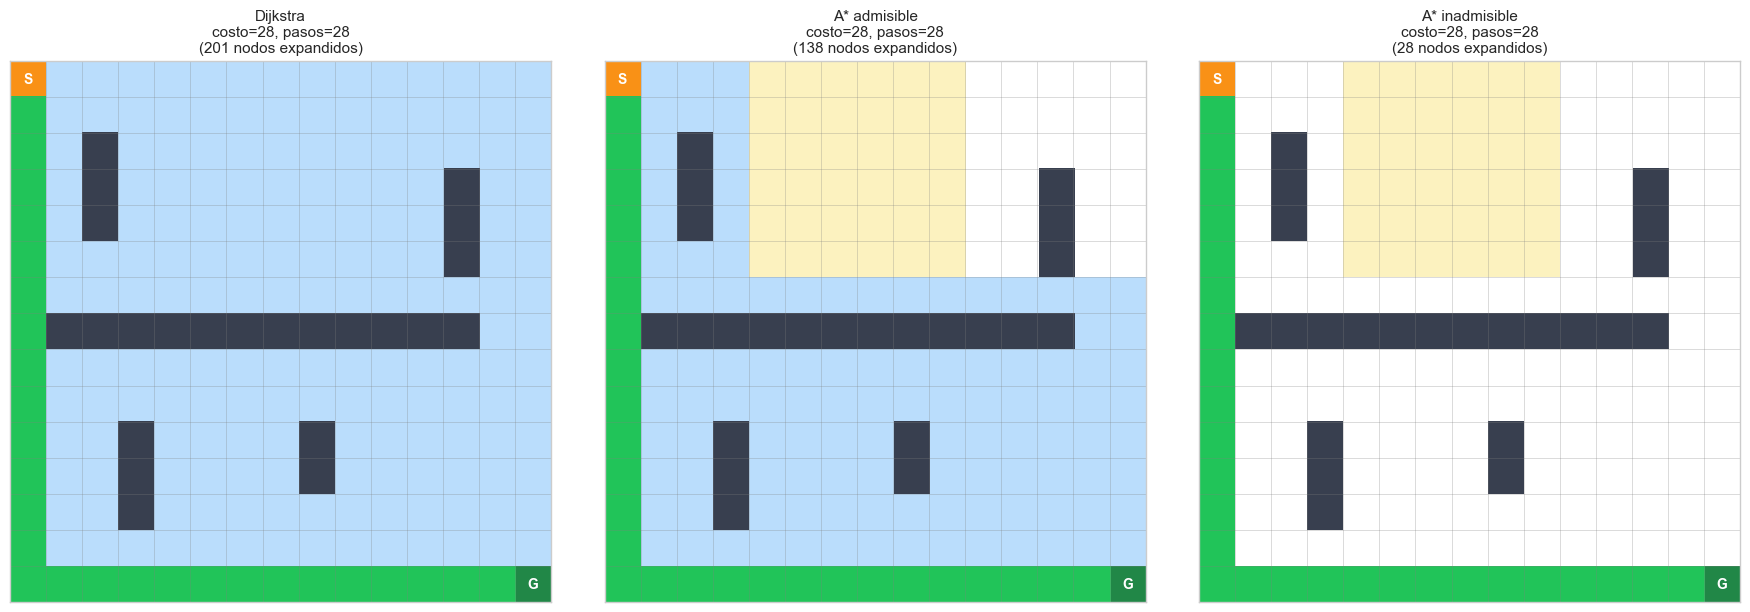


1) Camino devuelto por A* con h_inad:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (14, 1), (14, 2), (14, 3), (14, 4), (14, 5), (14, 6), (14, 7), (14, 8), (14, 9), (14, 10), (14, 11), (14, 12), (14, 13), (14, 14)]

2) ¿Es óptimo?: Sí
   Costo A* inadmisible = 28, costo Dijkstra = 28

3) A* con h_inad expande menos nodos que A* admisible.
   exp_inad=28, exp_admisible=138

4) ¿Por qué rompe la optimalidad?
   Porque al sobreestimar h(n), la prioridad f(n)=g(n)+h(n) puede favorecer rutas
   aparentemente cercanas a la meta pero con mayor costo real, haciendo que A*
   deje de comportarse como búsqueda de costo óptimo.


In [14]:
# Usa el laberinto 15×15 del notebook
prob_ej3 = prob_15

def h_admisible(nodo):
    return prob_ej3.heuristica_manhattan(nodo)

def h_inadmisible(nodo):
    """Heurística inadmisible: sobreestima el costo restante."""
    return prob_ej3.heuristica_manhattan(nodo) * 2

camino_d, exp_d, expl_d = dijkstra(prob_ej3)
camino_a, exp_a, expl_a = a_star(prob_ej3, h_admisible)
camino_inad, exp_inad, expl_inad = a_star(prob_ej3, h_inadmisible)

assert camino_d is not None and camino_a is not None and camino_inad is not None, "Alguno de los algoritmos no encontró camino"

costo_d = costo_total_camino(prob_ej3, camino_d)
costo_a = costo_total_camino(prob_ej3, camino_a)
costo_inad = costo_total_camino(prob_ej3, camino_inad)

print(f"{'Algoritmo':<22} {'Expandidos':>12} {'Pasos':>8} {'Costo':>8}")
print("-" * 54)
print(f"{'Dijkstra':<22} {exp_d:>12} {len(camino_d)-1:>8} {costo_d:>8}")
print(f"{'A* (h admisible)':<22} {exp_a:>12} {len(camino_a)-1:>8} {costo_a:>8}")
print(f"{'A* (h inadmisible)':<22} {exp_inad:>12} {len(camino_inad)-1:>8} {costo_inad:>8}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
comparacion = [
    ('Dijkstra', camino_d, expl_d, costo_d),
    ('A* admisible', camino_a, expl_a, costo_a),
    ('A* inadmisible', camino_inad, expl_inad, costo_inad),
]
for ax, (nombre, camino, explorados, costo) in zip(axes, comparacion):
    titulo = f"{nombre}\ncosto={costo}, pasos={len(camino)-1}"
    visualizar_grid(prob_ej3, camino=camino, explorados=explorados,
                    titulo=titulo, ax=ax, mostrar_conteo=True)
plt.tight_layout()
plt.show()

print("\n1) Camino devuelto por A* con h_inad:")
print(camino_inad)

es_optimo = (costo_inad == costo_d)
print("\n2) ¿Es óptimo?:", "Sí" if es_optimo else "No")
print(f"   Costo A* inadmisible = {costo_inad}, costo Dijkstra = {costo_d}")

if exp_inad < exp_a:
    comparacion_exp = "menos"
elif exp_inad > exp_a:
    comparacion_exp = "más"
else:
    comparacion_exp = "igual"

print(f"\n3) A* con h_inad expande {comparacion_exp} nodos que A* admisible.")
print(f"   exp_inad={exp_inad}, exp_admisible={exp_a}")

print("\n4) ¿Por qué rompe la optimalidad?")
print("   Porque al sobreestimar h(n), la prioridad f(n)=g(n)+h(n) puede favorecer rutas")
print("   aparentemente cercanas a la meta pero con mayor costo real, haciendo que A*")
print("   deje de comportarse como búsqueda de costo óptimo.")

---
## Ejercicio 4

Construye una **tabla comparativa** ejecutando los tres algoritmos en 5 configuraciones
distintas de laberinto y registrando el número de nodos expandidos.

Varía al menos un factor entre configuraciones: tamaño, densidad de paredes,
presencia/ausencia de terreno costoso, posición de la pared principal.

Presenta los resultados en una tabla legible (puedes usar `pandas` si está disponible,
o simplemente `print` con formato).

**Pregunta de análisis:** ¿En qué tipo de configuración la ventaja de A\* sobre
Dijkstra es mayor?

A* es mejor que Dijkstra en casos donde los grafos son mas densos En estos casos la heuristica de manhattan es mejor y no busca en lugares que no va a llegar. 

In [ ]:
# Ejercicio 4: tabla comparativa en 5 configuraciones
def grid_vacio(filas, cols):
    return [['.' for _ in range(cols)] for _ in range(filas)]

def colocar_pared_h(grid, fila, c_ini, c_fin, aberturas=None):
    aberturas = set(aberturas or [])
    for c in range(c_ini, c_fin + 1):
        if c not in aberturas:
            grid[fila][c] = '#'

def colocar_pared_v(grid, col, r_ini, r_fin, aberturas=None):
    aberturas = set(aberturas or [])
    for r in range(r_ini, r_fin + 1):
        if r not in aberturas:
            grid[r][col] = '#'

def contar_celdas(grid, valor):
    return sum(1 for fila in grid for celda in fila if celda == valor)

# Configuración 1: 10x10, baja densidad, sin terreno costoso
g1 = grid_vacio(10, 10)
for r, c in [(2, 2), (2, 3), (3, 2), (6, 7), (7, 6), (7, 7)]:
    g1[r][c] = '#'

# Configuración 2: 10x10, pared principal horizontal, sin terreno costoso
g2 = grid_vacio(10, 10)
colocar_pared_h(g2, fila=5, c_ini=1, c_fin=8, aberturas=[6])
colocar_pared_v(g2, col=3, r_ini=1, r_fin=8, aberturas=[4])

# Configuración 3: 12x12, paredes + zona costosa
g3 = grid_vacio(12, 12)
colocar_pared_h(g3, fila=4, c_ini=2, c_fin=9, aberturas=[7])
colocar_pared_h(g3, fila=8, c_ini=1, c_fin=10, aberturas=[3])
colocar_pared_v(g3, col=6, r_ini=1, r_fin=8, aberturas=[2, 6])
for r in range(1, 6):
    if g3[r][1] != '#':
        g3[r][1] = 'S'
for c in range(1, 5):
    if g3[0][c] != '#':
        g3[0][c] = 'S'

# Configuración 4: 15x15, mayor densidad de paredes, sin terreno costoso
g4 = grid_vacio(15, 15)
colocar_pared_h(g4, fila=5, c_ini=1, c_fin=13, aberturas=[2, 11])
colocar_pared_h(g4, fila=10, c_ini=1, c_fin=13, aberturas=[7])
colocar_pared_v(g4, col=4, r_ini=1, r_fin=13, aberturas=[3, 9])
colocar_pared_v(g4, col=9, r_ini=1, r_fin=13, aberturas=[6, 12])

# Configuración 5: 15x15, paredes desplazadas + terreno costoso, meta invertida
g5 = grid_vacio(15, 15)
colocar_pared_h(g5, fila=7, c_ini=0, c_fin=13, aberturas=[1, 12])
colocar_pared_v(g5, col=7, r_ini=1, r_fin=14, aberturas=[5, 10])
for r in range(8, 14):
    for c in range(2, 7):
        if g5[r][c] != '#':
            g5[r][c] = 'S'
for r in range(2, 6):
    for c in range(9, 13):
        if g5[r][c] != '#':
            g5[r][c] = 'S'

configuraciones = [
    {'nombre': 'C1_10x10_bajo_muro',    'grid': g1, 'inicio': (0, 0),  'meta': (9, 9),   'terrain': {'.': 1, 'S': 3}},
    {'nombre': 'C2_10x10_pared_centro', 'grid': g2, 'inicio': (0, 0),  'meta': (9, 9),   'terrain': {'.': 1, 'S': 3}},
    {'nombre': 'C3_12x12_con_costoso',  'grid': g3, 'inicio': (0, 0),  'meta': (11, 11), 'terrain': {'.': 1, 'S': 3}},
    {'nombre': 'C4_15x15_muy_denso',    'grid': g4, 'inicio': (0, 0),  'meta': (14, 14), 'terrain': {'.': 1, 'S': 3}},
    {'nombre': 'C5_15x15_denso_costoso','grid': g5, 'inicio': (14, 0), 'meta': (0, 14),  'terrain': {'.': 1, 'S': 3}},
]

resultados_tabla = []

for cfg in configuraciones:
    prob = GridProblem(cfg['grid'], cfg['inicio'], cfg['meta'], terrain_cost=cfg['terrain'])
    h = prob.heuristica_manhattan

    c_g, exp_g, _ = greedy(prob, h)
    c_d, exp_d, _ = dijkstra(prob)
    c_a, exp_a, _ = a_star(prob, h)

    # Asegurar que exista ruta en la configuración
    assert c_d is not None and c_a is not None, f"Sin ruta en {cfg['nombre']}"

    ct_g = costo_total_camino(prob, c_g) if c_g else None
    ct_d = costo_total_camino(prob, c_d) if c_d else None
    ct_a = costo_total_camino(prob, c_a) if c_a else None

    resultados_tabla.append({
        'Configuración': cfg['nombre'],
        'Tamaño': f"{prob.filas}x{prob.cols}",
        'Paredes': contar_celdas(cfg['grid'], '#'),
        'Celdas S': contar_celdas(cfg['grid'], 'S'),
        'Greedy exp': exp_g,
        'Dijkstra exp': exp_d,
        'A* exp': exp_a,
        'Costo Greedy': ct_g if ct_g is not None else '—',
        'Costo Dijkstra': ct_d if ct_d is not None else '—',
        'Costo A*': ct_a if ct_a is not None else '—',
        'Ventaja A* (exp)': exp_d - exp_a,
    })

# Tabla legible con print formateado
print(f"{'Configuración':<22} {'Tam':<8} {'#P':>4} {'#S':>4} {'G exp':>7} {'D exp':>7} {'A* exp':>8} {'Costo G':>8} {'Costo D':>8} {'Costo A*':>9} {'D-A*':>6}")
print("-" * 108)
for r in resultados_tabla:
    print(
        f"{r['Configuración']:<22} {r['Tamaño']:<8} {r['Paredes']:>4} {r['Celdas S']:>4} "
        f"{r['Greedy exp']:>7} {r['Dijkstra exp']:>7} {r['A* exp']:>8} "
        f"{str(r['Costo Greedy']):>8} {str(r['Costo Dijkstra']):>8} {str(r['Costo A*']):>9} {r['Ventaja A* (exp)']:>6}"
    )

# Respuesta de análisis: ¿dónde A* le gana más a Dijkstra?
mejor_cfg = max(resultados_tabla, key=lambda x: x['Ventaja A* (exp)'])
print()
"guía mejor la búsqueda hacia la meta y evita exploración lateral innecesaria."


Configuración          Tam        #P   #S   G exp   D exp   A* exp  Costo G  Costo D  Costo A*   D-A*
------------------------------------------------------------------------------------------------------------
C1_10x10_bajo_muro     10x10       6    0      18      93       92       18       18        18      1
C2_10x10_pared_centro  10x10      13    0      18      86       80       18       18        18      6
C3_12x12_con_costoso   12x12      20    9      22     123       67       22       22        22     56
C4_15x15_muy_denso     15x15      41    0      28     183      156       28       28        28     27
C5_15x15_denso_costoso 15x15      23   46      28     196       81       28       28        28    115

Análisis:
La mayor ventaja de A* sobre Dijkstra aparece en 'C5_15x15_denso_costoso', con una reducción de 115 nodos expandidos.
Esto suele ocurrir en configuraciones más grandes/densas, donde la heurística de Manhattan guía mejor la búsqueda hacia la meta y evita exploración la